In [24]:
!wget -q "https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/main/Task%201/API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv" -O population.csv
!wget -q "https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/main/Task%201/Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv" -O metadata.csv
print("Download complete.")


Download complete.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [26]:
df = pd.read_csv("population.csv", skiprows=4)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
latest_year = "2024"
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0


In [27]:
meta = pd.read_csv("metadata.csv")
real_country_codes = meta[meta["Region"].notna() & (meta["Region"] != "")]["Country Code"].tolist()
countries_df = df[df["Country Code"].isin(real_country_codes)].copy()
countries_df = countries_df[["Country Name", "Country Code", latest_year]].dropna()
countries_df[latest_year] = countries_df[latest_year].astype(float)
print(f"Total countries analyzed: {len(countries_df)}")
countries_df.head()


Total countries analyzed: 217


,Country Name,Country Code,2024
0,Aruba,ABW,107624.0
2,Afghanistan,AFG,42647492.0
4,Angola,AGO,37885849.0
5,Albania,ALB,2714617.0
6,Andorra,AND,81938.0


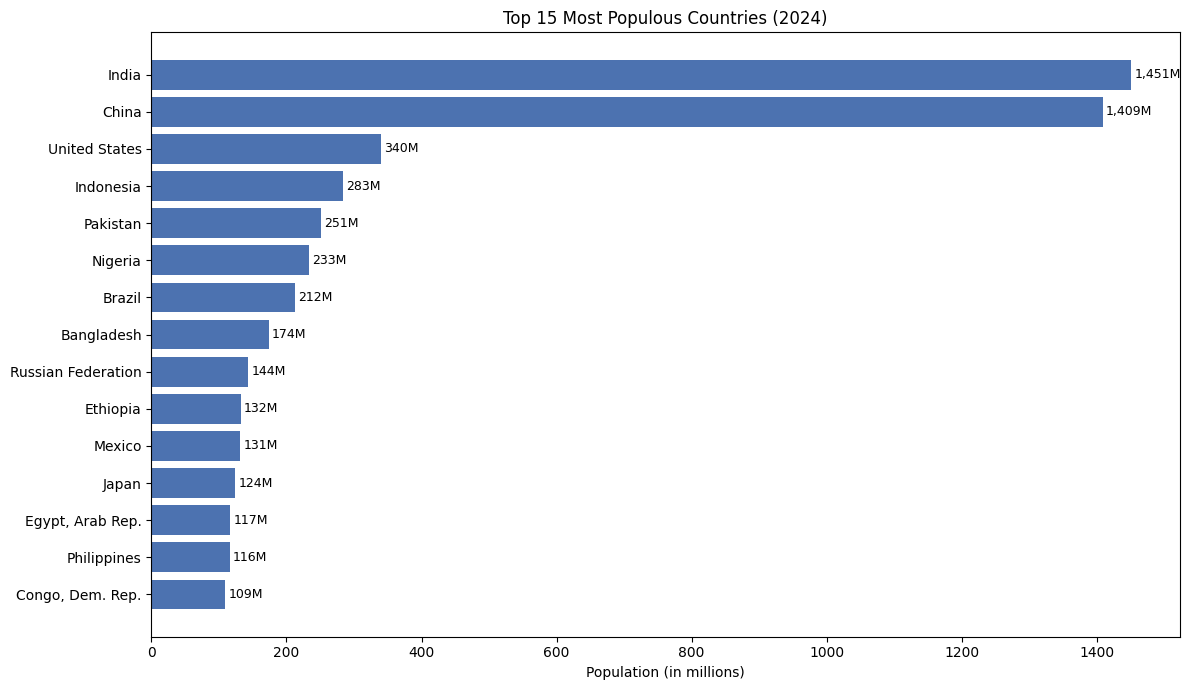

In [28]:
top15 = countries_df.sort_values(by=latest_year, ascending=False).head(15)
plt.figure(figsize=(12, 7))
bars = plt.barh(top15["Country Name"][::-1], top15[latest_year][::-1] / 1e6, color="#4C72B0")
plt.xlabel("Population (in millions)")
plt.title(f"Top 15 Most Populous Countries ({latest_year})")
plt.tight_layout()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
              f"{width:,.0f}M", va="center", fontsize=9)
plt.savefig("bar_chart_top15_countries.png", dpi=150)
plt.show()


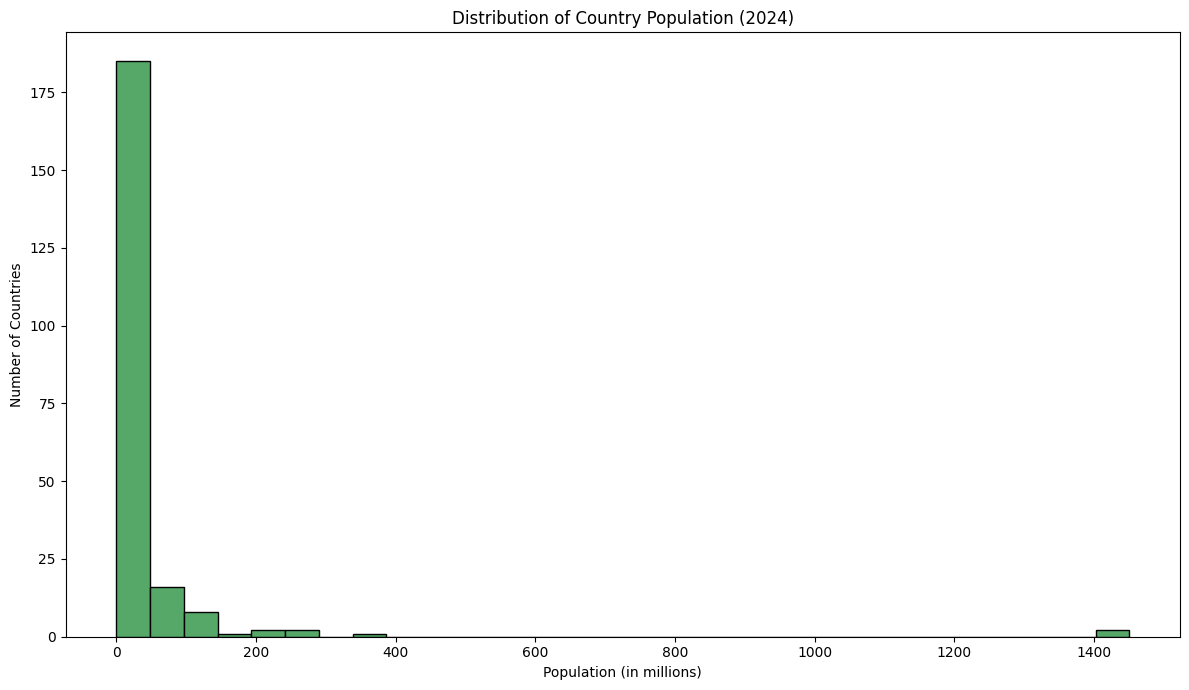

In [29]:
plt.figure(figsize=(12, 7))
plt.hist(countries_df[latest_year] / 1e6, bins=30, color="#55A868", edgecolor="black")
plt.xlabel("Population (in millions)")
plt.ylabel("Number of Countries")
plt.title(f"Distribution of Country Population ({latest_year})")
plt.tight_layout()
plt.savefig("histogram_population_distribution.png", dpi=150)
plt.show()


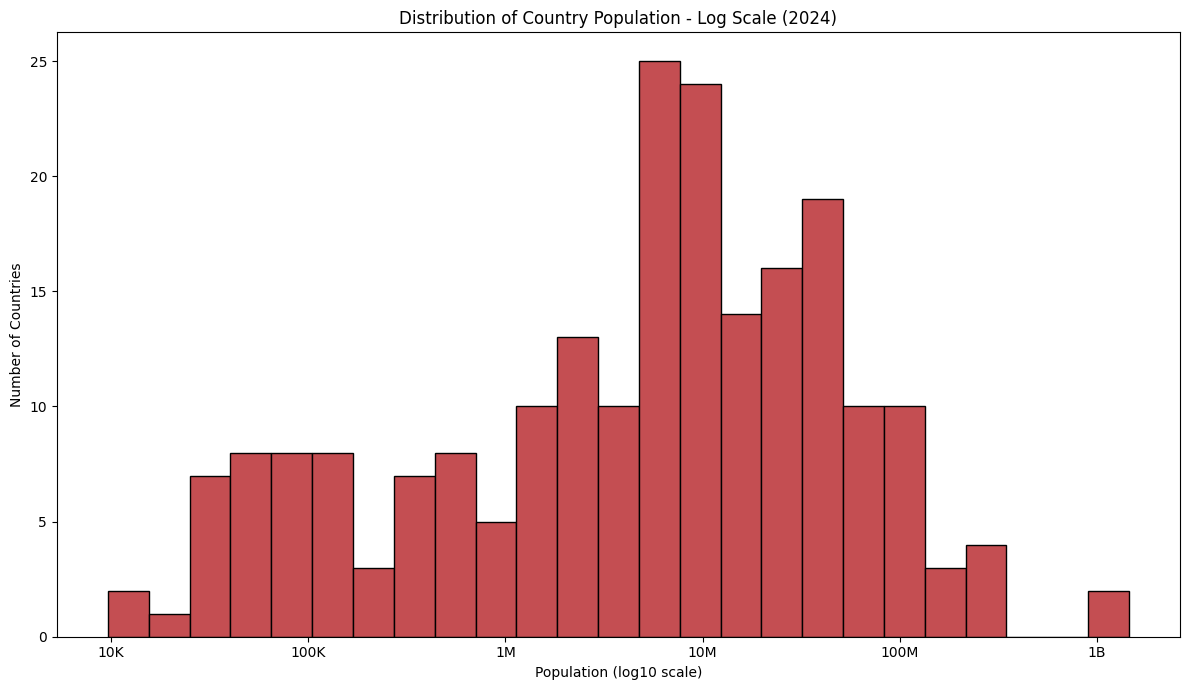

In [30]:
plt.figure(figsize=(12, 7))
log_pop = np.log10(countries_df[latest_year])
plt.hist(log_pop, bins=25, color="#C44E52", edgecolor="black")
plt.xlabel("Population (log10 scale)")
plt.ylabel("Number of Countries")
plt.title(f"Distribution of Country Population - Log Scale ({latest_year})")
xticks = [4, 5, 6, 7, 8, 9]
xtick_labels = ["10K", "100K", "1M", "10M", "100M", "1B"]
plt.xticks(xticks, xtick_labels)
plt.tight_layout()
plt.savefig("histogram_population_log_scale.png", dpi=150)
plt.show()


In [31]:
print("Top 15 countries by population:")
print(top15[["Country Name", latest_year]].to_string(index=False))
print(f"\nTotal countries analyzed: {len(countries_df)}")


Top 15 countries by population:
      Country Name         2024
             India 1450935791.0
             China 1408975000.0
     United States  340110988.0
         Indonesia  283487931.0
          Pakistan  251269164.0
           Nigeria  232679478.0
            Brazil  211998573.0
        Bangladesh  173562364.0
Russian Federation  143533851.0
          Ethiopia  132059767.0
            Mexico  130861007.0
             Japan  123975371.0
  Egypt, Arab Rep.  116538258.0
       Philippines  115843670.0
  Congo, Dem. Rep.  109276265.0

Total countries analyzed: 217
